In [4]:
'''
Test to verify that the Gravelamps isolated point-mass and phenomenological-lensing models works correctly within the DINGO-Lensing waveform generator framework
'''

'\nTest to verify that the Gravelamps isolated point-mass and phenomenological-lensing models works correctly within the DINGO-Lensing waveform generator framework\n'

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from dingo.gw.domains import build_domain
from dingo_lensing.waveform_generator import LensedWaveformGenerator

In [6]:
domain_settings = {
    "type": "FrequencyDomain",
    "f_min": 20.0,
    "f_max": 1024.0,
    "delta_f": 0.125,
}
domain = build_domain(domain_settings)


parameters_pm = {
    "mass_1": 30.0,
    "mass_2": 30.0,
    "phase": 0.0,
    "geocent_time": 0.0,
    "luminosity_distance": 1000.0, 
    "a_1": 0.0,
    "a_2": 0.0,
    "tilt_1": 0.0,
    "tilt_2": 0.0,
    "phi_12": 0.0,
    "phi_jl": 0.0,
    "theta_jn": 0.0,
    "psi": 0.0,
    "ra": 0.0,
    "dec": 0.0,
    # --- Gravelamps PM parameters---
    "lens_mass": 1000.0,              
    "lens_fractional_distance": 0.5,  
    "source_position": 0.1,
}

parameters_phenom = {
    "mass_1": 30.0,
    "mass_2": 30.0,
    "phase": 0.0,
    "geocent_time": 0.0,
    "luminosity_distance": 1000.0, 
    "a_1": 0.0,
    "a_2": 0.0,
    "tilt_1": 0.0,
    "tilt_2": 0.0,
    "phi_12": 0.0,
    "phi_jl": 0.0,
    "theta_jn": 0.0,
    "psi": 0.0,
    "ra": 0.0,
    "dec": 0.0,
    # --- Gravelamps PhenomLensing parameters---
    #Note that you have to add more lens parameters as you increase "num_images"
    "num_images":3,
    "n0": 0.0,
    "n1": 0.5,
    "n2": 1.0,
    "mu_rel1": 0.8,
    "mu_rel2": 1.2,
    "dt1": 0.01,
    "dt2": 0.03,
}

Setting spin_conversion_phase = None. Using phase parameter for conversion to cartesian spins.
Setting spin_conversion_phase = None. Using phase parameter for conversion to cartesian spins.


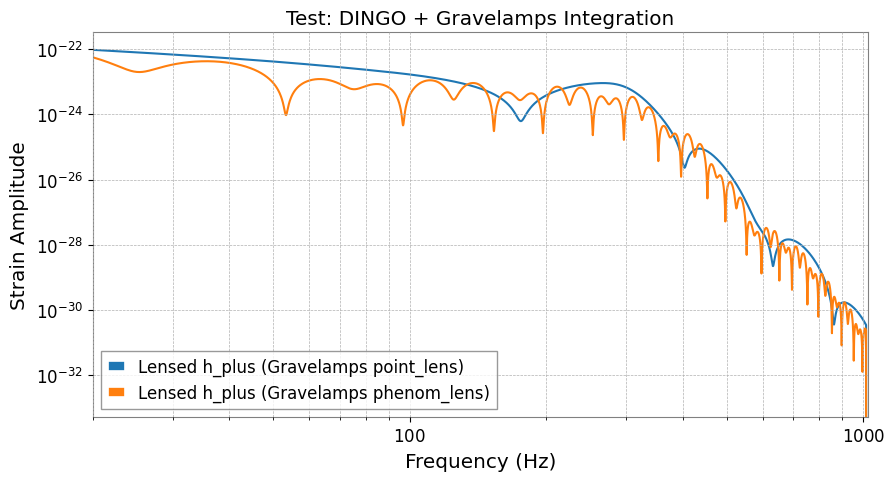

In [14]:
%matplotlib inline

wfg_pm = LensedWaveformGenerator(
    domain=domain,
    approximant="IMRPhenomXPHM",            
    f_ref=20.0,
    lens_model_code="gravelamps",          
    amplification_factor_function="gravelamps_pointlens",
    lens_model_settings={"geo_switch": 1000,"precision": 1000}
)

wfg_phenom = LensedWaveformGenerator(
    domain=domain,
    approximant="IMRPhenomXPHM",            
    f_ref=20.0,
    lens_model_code="gravelamps",          
    amplification_factor_function="gravelamps_phenom",
    lens_model_settings={"max_num_images": 6}
)

polarizations_pm = wfg_pm.generate_hplus_hcross(parameters_pm.copy())
polarizations_phenom = wfg_phenom.generate_hplus_hcross(parameters_phenom.copy())


freqs = domain.sample_frequencies

h_plus_pm = polarizations_pm["h_plus"]
h_plus_phenom = polarizations_phenom["h_plus"]

plt.figure(figsize=(10, 5))
plt.loglog(freqs, np.abs(h_plus_pm), label="Lensed h_plus (Gravelamps point_lens)")
plt.loglog(freqs, np.abs(h_plus_phenom), label="Lensed h_plus (Gravelamps phenom_lens)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Strain Amplitude")
plt.xlim(20, 1024)
plt.legend()
plt.title("Test: DINGO + Gravelamps Integration")
plt.grid(True, which="both", ls="--")
plt.show()
#plt.savefig('test.pdf',dpi=300)